# Analyzing Data from UQAM 

*Last updated April 28, 2026*

Here, we go through some plotting & analysis of the data available from [the Theriault group at UQAM](https://borealisdata.ca/dataset.xhtml?persistentId=doi:10.5683/SP3/QFYOHG&version=1.2). Note that the dataset contains measurements from two stations: one at UQAM and the other at a residential home in Morin Heights, QC. Most of our analysis will focus on the UQAM data, but for the sake of completeness I also show some results from Morin Heights. 

This notebook assumes you have already downloaded and unpacked the data. The directory structure used for loading data here will be clear from context, and in any case it can easily be changed to accommodate your preferences. 

In [1]:
from datetime import datetime as dt

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

plt.rc("font", family="serif")

## Station 1: UQAM

First we need functions for loading all the data from the UQAM station. 

In [2]:
def get_df_one_date(
    filename, 
    base_path = "UQAMGroundStationData/UQAM/", 
    date = "20230405", 
    file_extension = ".txt",
):
    """
    Reads one day's worth of data from the UQAM station into memory as a dataframe. 
    """
    df = pd.read_table(
        base_path + filename + date + file_extension, 
        index_col = ["Timestamp"],
        parse_dates = ["Timestamp"], 
        date_format = "%Y-%m-%d %H:%M"
    )
    df.index = pd.to_datetime(df.index)
    return df 

def get_df(filename, 
    base_path = "UQAMGroundStationData/UQAM/", 
    dates = ["20230405", "20230406"],
    file_extension = ".txt"
):
    """
    Reads a range of daily data from the UQAM station into memory as a dataframe. 
    """
    dfs = [
        get_df_one_date(
            filename, 
            base_path = base_path, 
            date = date, 
            file_extension = file_extension
        )
        for date in dates
    ]
    return pd.concat(dfs)

In [15]:
def nice_plot(
    df,
    ylabel = None,
    save_fig = False, 
    show_fig = False, 
    color = "xkcd:ocean blue", 
    outfile_name = "image",
):
    """
    Produce a nice plot from a dataframe (or data series). 
    """
    ax = df.plot(color = color, linewidth = 1.8)
    plt.xlabel("Time (UTC)", fontsize = 18)
    plt.ylabel(ylabel, fontsize = 18)
    plt.grid(visible = True, which = "both")
    ax.tick_params(axis='both', which='both', labelsize=16)

    if save_fig: 
        plt.savefig(outfile_name + ".png", dpi=600, bbox_inches="tight")
    
    if show_fig:
        plt.show()

    return None

Load in all our data: 

In [16]:
df_met = get_df("UP_PR_MET_MAS_")
df_dis = get_df("UP_PR_DIS_MAS_")
df_geonor = get_df("UP_PR_GEONOR_MAS_")
df_ice = get_df("UP_PR_ICE_MAS_")

NOTE: From the data readme files, all times are reported in UTC. 

We only show results from April 5, 0900 UTC to April 6 0400 UTC. This shows the complete "lifetime" of the storm (identified via radar records), plus a little buffer at the beginning and end. 

In [17]:
start_time = "2023-04-05 12:00:00"
end_time = "2023-04-06 04:01:00"
last_recorded_time = "2023-04-06 04:00:00"

With all our preprocessing done, we can get to producing helpful plots. 

### Basic Meteorological Data

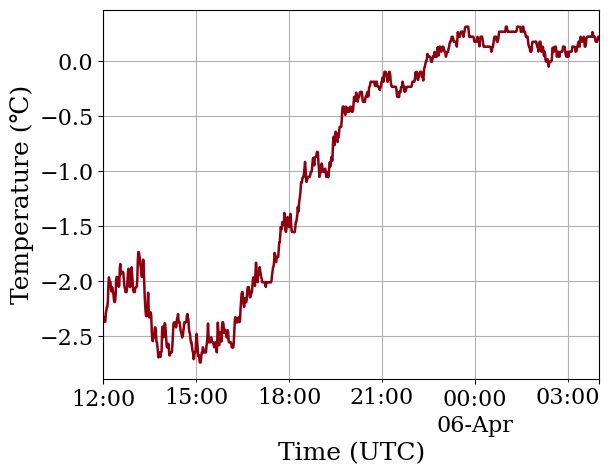

In [18]:
nice_plot(
    df_met["HMP_AirTemp"][start_time:end_time],
    ylabel = "Temperature (\N{DEGREE CELSIUS})",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:crimson",
    outfile_name = "uqam_temp",
)

### Disdrometer

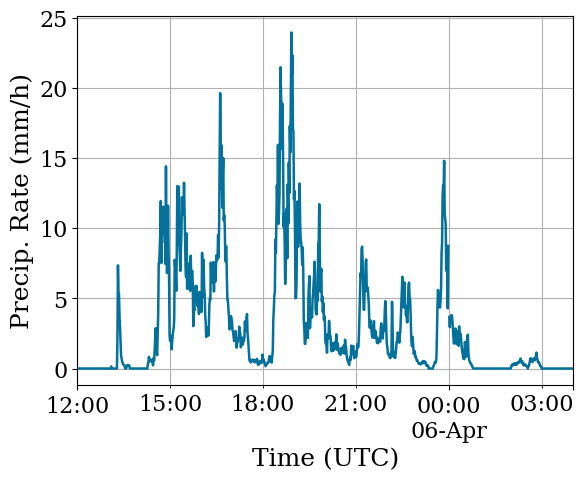

In [19]:
nice_plot(
    df_dis["Intensity_of_precipitation"][start_time:end_time],
    ylabel = "Precip. Rate (mm/h)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:ocean blue",
    outfile_name = "uqam_precip_rate",
)

In [20]:
df_dis["Intensity_of_precipitation"][start_time:end_time].max()

np.float64(23.952)

In [21]:
df_dis["Intensity_of_precipitation"][start_time:end_time][df_dis["Intensity_of_precipitation"] > 0].mean()

np.float64(4.072404285714286)

The Parsivel disdrometer only measured one sample where snow intensity was positive. 

In [22]:
df_dis["Snow_intensity"][start_time:end_time][df_dis["Snow_intensity"] > 0]

Timestamp
2023-04-05 17:15:00    1.38
Name: Snow_intensity, dtype: float64

### GEONOR Instrument

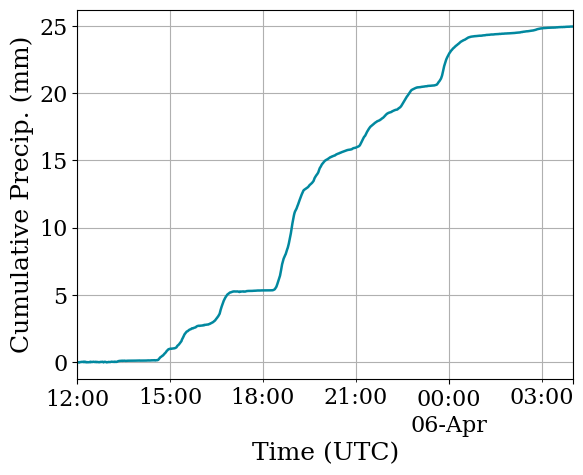

In [29]:
cumulative_precip_geonor = (
    df_geonor["GEONOR_TOTAL_Moyenne_3"][start_time:end_time] - df_geonor["GEONOR_TOTAL_Moyenne_3"][start_time]
)

nice_plot(
    cumulative_precip_geonor,
    ylabel = "Cumulative Precip. (mm)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:teal blue",
    outfile_name = "uqam_cumul_precip",
)

In [24]:
df_geonor["GEONOR_TOTAL_Moyenne_3"][start_time:end_time][end_time] - df_geonor["GEONOR_TOTAL_Moyenne_3"][start_time]

np.float64(24.945037841796875)

We also compare to the wind speed at St-Hubert weather station: 

In [25]:
df = pd.read_csv(
        "Mtl-StHubert-stn-data/" + "en_climate_hourly_QC_7027329_04-2023_P1H" + ".csv", 
        index_col = ["Date/Time (UTC)"],
        parse_dates = ["Date/Time (UTC)"], 
    )
df.index = pd.to_datetime(df.index)

df_pr = df["Precip. Amount (mm)"][start_time: end_time]

In [26]:
df_pr.sum()

np.float64(34.4)

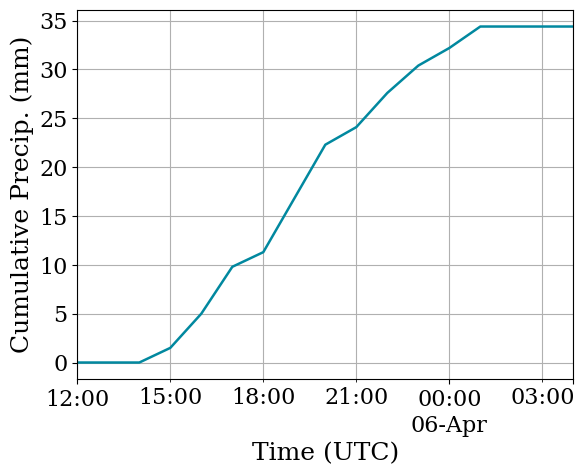

In [30]:
nice_plot(
    df_pr.cumsum(),
    ylabel = "Cumulative Precip. (mm)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:teal blue",
    outfile_name = "mtl_sthubert_cumul_precip",
)

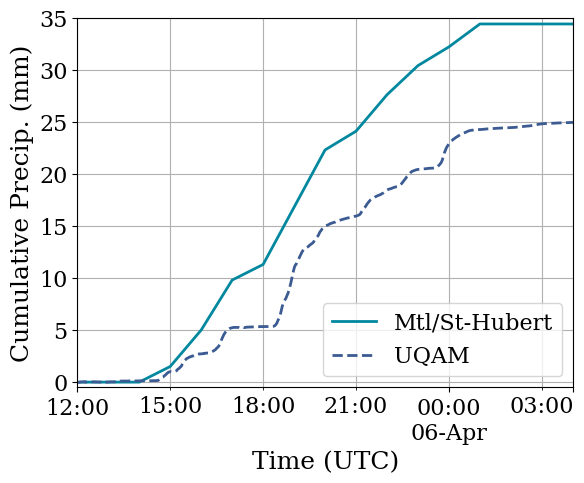

In [28]:
fig, ax = plt.subplots()

ax = df_pr.cumsum().plot(linestyle="solid", linewidth=2, color="xkcd:teal blue", label="Mtl/St-Hubert")
cumulative_precip_geonor.plot(ax=ax, linestyle="dashed", linewidth=2, color="xkcd:denim blue", label="UQAM")
plt.xlabel("Time (UTC)", fontsize = 18)
plt.ylabel("Cumulative Precip. (mm)", fontsize = 18)
plt.grid(visible = True, which = "both")
ax.tick_params(axis='both', which='both', labelsize=16)
plt.ylim(-0.5, 35)
plt.legend(fontsize=16, loc="lower right")
#plt.savefig("cumul_precip" + ".png", dpi=600, bbox_inches="tight")
plt.show()

### Ice Accumulation Meter 

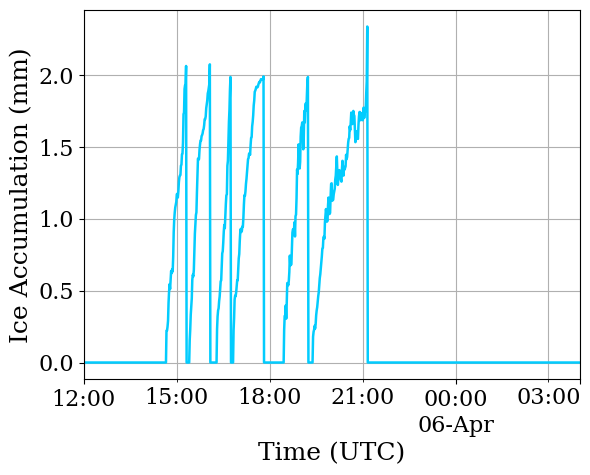

In [31]:
nice_plot(
    df_ice["Ice_mm"][start_time:end_time],
    ylabel = "Ice Accumulation (mm)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:bright sky blue",
    outfile_name = "uqam_ice",
)

The ice accumulation meter has a heater that turns on automatically to melt all collected ice and "start fresh". Therefore, we may get the total ice accumulation by summing over values at those times right before the heater turns on (these times are available in the `df_ice` dataframe). 

In [32]:
df_ice["Ice_mm"][start_time:end_time][df_ice["HeatTime"] > 0].sum()

np.float64(12.42817747592926)

Thus we may estimate the total ice accumulation at about $12.4$mm. 

## Morin Heights Data

Since I don't plan on using this data much in the report, I won't discuss the code here in much detail. 

In [33]:
def get_df_mh(filename):
    base_path = "UQAMGroundStationData/MH/"
    date = "202304"
    
    df = pd.read_csv(
        base_path + filename + date + ".txt", 
        index_col = ["Timestamp"],
        parse_dates = ["Timestamp"], 
        date_format = "%Y-%m-%d %H:%M",
    )
    df.index = pd.to_datetime(df.index)
    return df 

In [34]:
df_ice_mh = get_df_mh("LN_MH_ICE_MAS_")
df_met_mh = get_df_mh("LN_MH_MET_01_MAS_")
df_dis_mh = get_df_mh("LN_MH_DIS_MAS_")

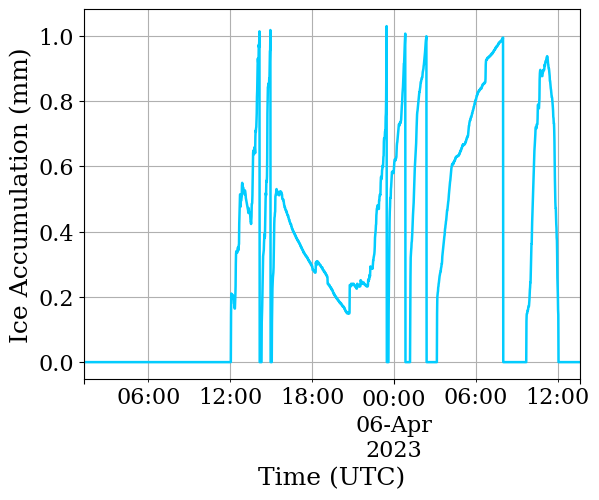

In [35]:
nice_plot(
    df_ice_mh["Ice_mm"],
    ylabel = "Ice Accumulation (mm)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:bright sky blue",
    outfile_name = "mh_ice",
)

In [36]:
df_ice_mh["Ice_mm"][df_ice_mh["HeatTime"] > 0].sum() 

np.float64(6.0569999999999995)

This accumulation estimate is smaller than that from the UQAM station, but the strange "dip" in the graph between April 5 1500 UTC and 2200 UTC leads me to believe there was some instrumentation issue. 

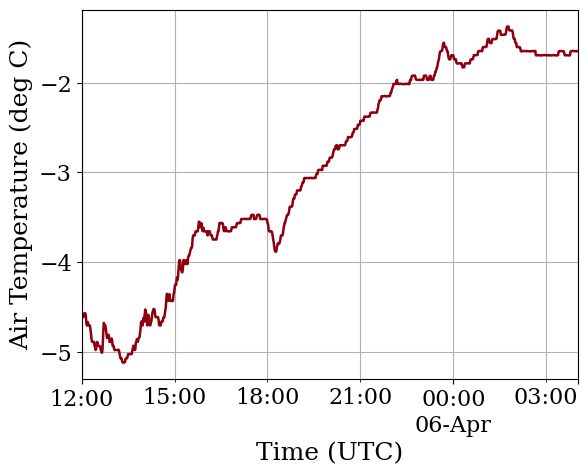

In [37]:
nice_plot(
    df_met_mh["Air_Temp"][start_time:end_time],
    ylabel = "Air Temperature (deg C)",
    save_fig = False, 
    show_fig = True,
    color = "xkcd:crimson",
    outfile_name = "mh_temp",
)